# <font color='blue'>Proyecto Final. Módulo 4.</font>
### <font color='red'>Fecha de entrega: 06 DE DICIEMBRE 2025 23:59 PM </font>
### Andrés Padrón Quintana 
### <font color='green'>Curso : DATA SCIENCE AND MACHINE LEARNING APPLIED TO FINANCIAL MARKETS </font>

La base de datos que estaremos usando durante el examen está relacionada con **campañas de marketing de instituciones financieras**. La base original tiene más de 40,000 registros, por lo que para efectos del examen estaremos usando una submuestra aleatoria del 10% de esta base, con 17 features variables. Este archivo se llama `bank.csv`. A reserva de que se diga lo contrario, la variable a pronosticar (target/y) será **"y" en la base de datos, la cual representa si el cliente contrató el producto financiero de "deposito a plazo"**

Les comparto mayor información de la base de datos. En el link, si gustan, podrán encontrar más (http://archive.ics.uci.edu/ml/datasets/Bank+Marketing)

```python
For more information, read [Moro et al., 2011].

Input variables:
# bank client data:
1 - age (numeric)
2 - job : type of job (categorical: "admin.","unknown","unemployed","management","housemaid","entrepreneur","student",
                                   "blue-collar","self-employed","retired","technician","services") 
3 - marital : marital status (categorical: "married","divorced","single"; note: "divorced" means divorced or widowed)
4 - education (categorical: "unknown","secondary","primary","tertiary")
5 - default: has credit in default? (binary: "yes","no")
6 - balance: average yearly balance, in euros (numeric) 
7 - housing: has housing loan? (binary: "yes","no")
8 - loan: has personal loan? (binary: "yes","no")
# related with the last contact of the current campaign:
9 - contact: contact communication type (categorical: "unknown","telephone","cellular") 
10 - day: last contact day of the month (numeric)
11 - month: last contact month of year (categorical: "jan", "feb", "mar", ..., "nov", "dec")
12 - duration: last contact duration, in seconds (numeric)
# other attributes:
13 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
14 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric, -1 means client was not previously contacted)
15 - previous: number of contacts performed before this campaign and for this client (numeric)
16 - poutcome: outcome of the previous marketing campaign (categorical: "unknown","other","failure","success")

Output variable (desired target):
17 - y - has the client subscribed a term deposit? (binary: "yes","no")
```


De esta forma pueden acceder directamente a la base sin necesidad de descargarla directamente: 

```python
import pandas as pd
from zipfile import ZipFile
from io import BytesIO
import urllib.request as urllib2

r = urllib2.urlopen("https://archive.ics.uci.edu/ml/machine-learning-databases/00222/bank.zip").read()
file = ZipFile(BytesIO(r))
bank = file.open("bank.csv")
bank = pd.read_csv(bank,sep=";")



In [2]:
import pandas as pd
from zipfile import ZipFile
from io import BytesIO
import urllib.request as urllib2

bank = pd.read_csv("bank.csv",sep=",")

In [3]:
bank.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,0
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,0
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,0
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,0
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,0


In [4]:
bank.shape

(4521, 17)

In [5]:
bank[bank.y==0].shape

(4000, 17)

In [6]:
bank[bank.y==1].shape

(521, 17)

# Parte 0. EDA

In [7]:
# Cargamos librerías

import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# 1) Estructura general del dataset
print("Dimensiones del dataset (filas, columnas):", bank.shape)

print("\nTipos de datos:")
print(bank.dtypes)

print("\nValores faltantes por columna:")
print(bank.isna().sum())


Dimensiones del dataset (filas, columnas): (4521, 17)

Tipos de datos:
age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
y             int64
dtype: object

Valores faltantes por columna:
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64


El conjunto de datos `bank` contiene **4521 observaciones** y **17 variables**.
De acuerdo con los tipos de datos, contamos con variables numéricas
(`age`, `balance`, `day`, `duration`, `campaign`, `pdays`, `previous`, `y`)
y variables categóricas (`job`, `marital`, `education`, `default`, `housing`,
`loan`, `contact`, `month`, `poutcome`).

En primer lugar, se verificó la presencia de valores faltantes. La salida
muestra que **todas las columnas tienen 0 valores faltantes**, por lo que no fue
necesario aplicar técnicas de imputación y se pudo trabajar directamente con la
base completa.

In [8]:
# 2) Resumen de variables numéricas
num_cols = bank.select_dtypes(include="number").columns
display(bank[num_cols].describe().T)

,count,mean,std,min,25%,50%,75%,max
age,4521.0,41.170095,10.576211,19.0,33.0,39.0,49.0,87.0
balance,4521.0,1422.657819,3009.638142,-3313.0,69.0,444.0,1480.0,71188.0
day,4521.0,15.915284,8.247667,1.0,9.0,16.0,21.0,31.0
duration,4521.0,263.961292,259.856633,4.0,104.0,185.0,329.0,3025.0
campaign,4521.0,2.793630,3.109807,1.0,1.0,2.0,3.0,50.0
pdays,4521.0,39.766645,100.121124,-1.0,-1.0,-1.0,-1.0,871.0
previous,4521.0,0.542579,1.693562,0.0,0.0,0.0,0.0,25.0
y,4521.0,0.115240,0.319347,0.0,0.0,0.0,0.0,1.0


En las variables numéricas se observan los siguientes patrones:

- `age` tiene una media cercana a **41 años** y un rango de **19 a 87**, con el
  50 % central de los clientes entre **33 y 49 años**, lo que indica una
  población predominantemente adulta.
- `balance` presenta una media de **1422** y una desviación estándar muy alta
  (**3009**), con valores entre **–3313** y **71 188**. La mediana es
  **444**, por lo que la distribución está fuertemente sesgada a la derecha:
  la mayoría de los clientes tiene saldos moderados y unos pocos presentan
  saldos muy elevados (o deudas importantes cuando el saldo es negativo).
- `duration` (duración de la llamada) tiene mediana de **185** segundos y
  máxima de **3025**. La diferencia entre media (**264**) y mediana sugiere
  una distribución también sesgada, con algunas llamadas excepcionalmente largas.
- `campaign` (número de contactos durante la campaña) se concentra en valores
  bajos: mediana **2** y tercer cuartil **3**, por lo que la mayoría de los
  clientes fue contactada pocas veces.
- `pdays` y `previous` indican la historia de contactos previos. En `pdays`
  los cuartiles están en **–1**, lo que señala que para la mayoría de los
  clientes no hubo contacto previo reciente; sin embargo, el máximo de **871**
  días y la alta desviación estándar reflejan algunos casos con historial
  antiguo. En `previous`, el 75 % de los clientes tiene **0** contactos
  previos, y solo unos pocos llegan hasta **25**.


Distribución de la variable objetivo y (frecuencias absolutas):
y
0    4000
1     521
Name: count, dtype: int64

Distribución de la variable objetivo y (porcentajes):
y
0    0.885
1    0.115
Name: proportion, dtype: float64


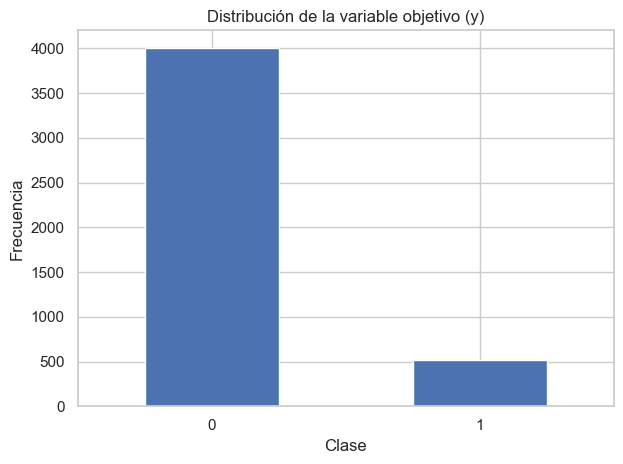

In [10]:
# 3) Distribución de la variable objetivo
print("\nDistribución de la variable objetivo y (frecuencias absolutas):")
print(bank["y"].value_counts())

print("\nDistribución de la variable objetivo y (porcentajes):")
print(bank["y"].value_counts(normalize=True).round(3))

fig, ax = plt.subplots()
bank["y"].value_counts().sort_index().plot(kind="bar", ax=ax)
ax.set_title("Distribución de la variable objetivo (y)")
ax.set_xlabel("Clase")
ax.set_ylabel("Frecuencia")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()

La variable objetivo `y` está codificada como 0/1, donde `0` indica que el
cliente **no** contrata el producto y `1` indica que **sí** lo contrata.
En la base de datos se observan:

- **4000** observaciones con `y = 0` (**88.5 %**)
- **521** observaciones con `y = 1` (**11.5 %**)

Es decir, por cada cliente que contrata el producto hay aproximadamente
**8 clientes que no lo hacen**, lo que confirma que se trata de un problema
claramente **desbalanceado**. Este desbalance se aprecia también en el
gráfico de barras de la Figura de arriba (distribución de la variable objetivo),
donde la barra correspondiente a la clase `0` domina casi por completo.

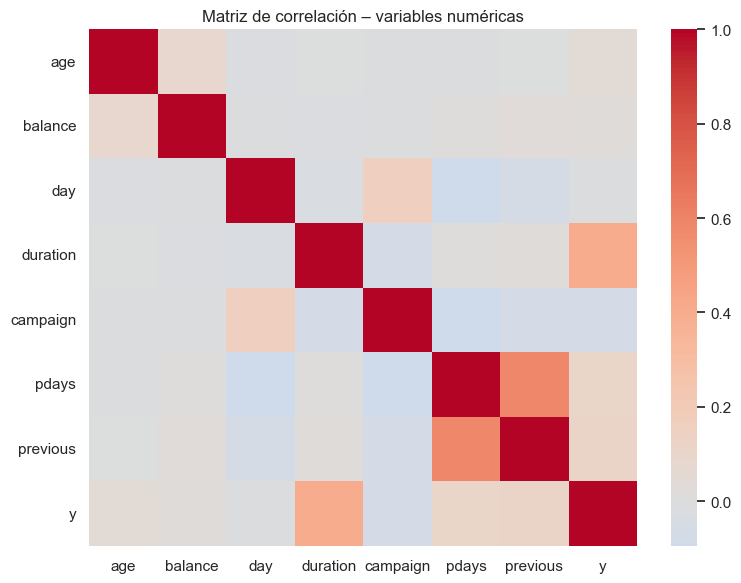

In [11]:
# 4) Matriz de correlación de variables numéricas
if len(num_cols) > 1:
    plt.figure(figsize=(8, 6))
    sns.heatmap(bank[num_cols].corr(), annot=False, cmap="coolwarm", center=0)
    plt.title("Matriz de correlación – variables numéricas")
    plt.tight_layout()
    plt.show()

En la Figura de arriba se muestra la matriz de correlación entre las variables numéricas
(`age`, `balance`, `day`, `duration`, `campaign`, `pdays`, `previous` y `y`).
En general, **no se observan correlaciones extremas** entre los predictores:
la mayoría de los coeficientes se mantiene en valores bajos o moderados, lo que
indica que no hay problemas severos de colinealidad para ajustar modelos
lineales.

Las correlaciones más visibles se dan entre:

- `duration` y la variable objetivo `y`, donde se aprecia una correlación
  **positiva**: las campañas con llamadas más largas tienden a asociarse con
  una mayor probabilidad de que el cliente contrate el producto.
- `campaign` y `y`, donde la relación es más bien **negativa**: conforme aumenta
  el número de intentos de contacto, la probabilidad de éxito marginal tiende a
  disminuir.
- `pdays` y `previous`, que muestran una correlación positiva al reflejar la
  historia de contactos previos con el cliente.

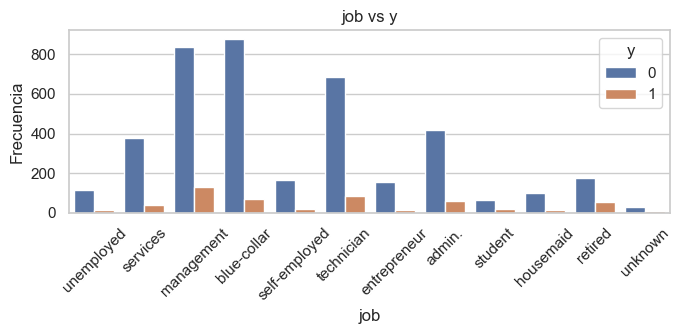

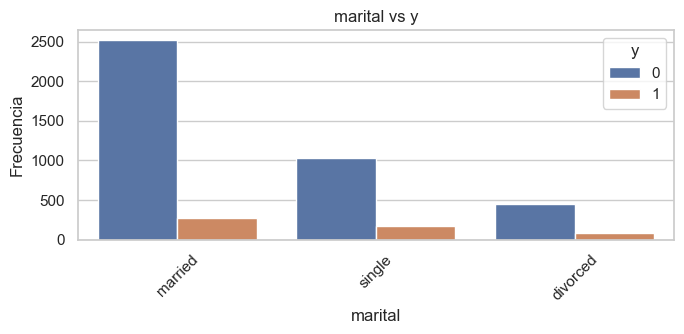

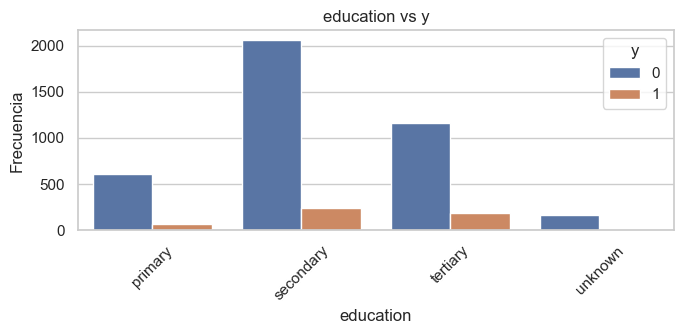

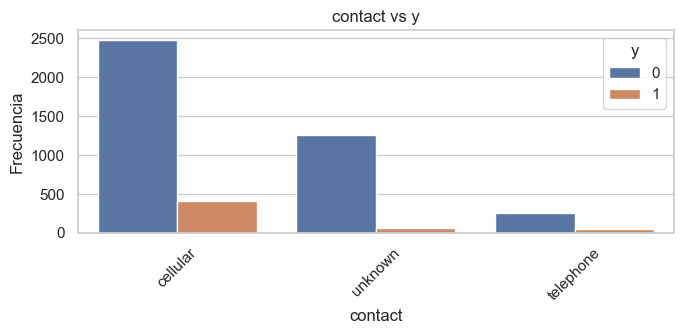

In [12]:
# 5) Algunas categóricas vs la variable objetivo
cat_cols = bank.select_dtypes(include="object").columns.tolist()
cols_to_plot = [c for c in ["job", "marital", "education", "contact"] if c in cat_cols]

for col in cols_to_plot:
    plt.figure(figsize=(7, 3.5))
    sns.countplot(data=bank, x=col, hue="y")
    plt.title(f"{col} vs y")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.xticks(rotation=45)
    plt.legend(title="y")
    plt.tight_layout()
    plt.show()

También se analizó la relación entre algunas variables categóricas clave
(`job`, `marital`, `education` y `contact`) y la variable objetivo `y`.

En la gráfica **job vs y** se observa que los grupos más frecuentes son
*management*, *blue-collar*, *technician* y *admin.*. En todos los tipos de
ocupación hay muy pocos clientes que contratan el producto (barras naranjas),
pero destaca que, en términos absolutos, la mayoría de los éxitos se concentra
en los segmentos con más clientes (principalmente *management*, *technician* y
*blue-collar*). Esto sugiere que el perfil ocupacional aporta información
relevante para explicar la probabilidad de respuesta.

En **marital vs y**, el grupo *married* domina en número total de clientes, pero
la proporción de respuestas positivas parece algo mayor en los segmentos
*single* y *divorced* que en *married*. Es decir, aunque hay más personas
casadas en la base, los clientes solteros o divorciados muestran una ligera
tendencia a aceptar el producto con mayor frecuencia.

En **education vs y**, la mayoría de los clientes tiene estudios *secondary*,
seguido de *tertiary* y *primary*. Visualmente, los niveles *secondary* y
*tertiary* concentran la mayor parte de las contrataciones exitosas, lo que
apunta a que el nivel educativo también influye en la respuesta a la campaña.

Por último, en **contact vs y** se aprecia que la gran mayoría de los contactos
se realiza por **celular**, y es precisamente en este medio donde se observa el
mayor número de respuestas positivas. Los contactos catalogados como *unknown*
o *telephone* son mucho menos frecuentes y generan muy pocos éxitos. Esto
sugiere que el canal de contacto es un factor importante para el desempeño de
la campaña.

- Para dividir Train-Test-Set `seed=1`
- Escoge la metrica que mejor se ajuste a este conjunto de datos para medir el rendimiento de tus modelos (accuracy,precision,recall, etc) y con base en tu elección trabaja las siguientes partes. 

***Elección de la métrica de evaluación***
En este proyecto utilizaré el ROC–AUC como métrica principal para comparar modelos. La base bank está desbalanceada (la clase positiva es mucho menos frecuente), por lo que la accuracy simple puede ser engañosa. El ROC–AUC resume la capacidad de discriminación del modelo en todos los posibles umbrales y es menos sensible al desbalance de clases.
Como métricas complementarias reportaré la balanced accuracy, el recall de la clase positiva y la matriz de confusión, y ajustaré el umbral de decisión usando el criterio de Youden para no perder demasiados clientes potenciales.

**random_state=1 es justo el seed=1**

# Parte 1. Regresión Logística


1. Utiliza la base de `bank` mencionada al inicio del documento. 
2. Ajusta el mejor modelo que encuentres utilizando una regresión logística para explicar si cliente contrató el producto o no. (usa tambien l1 y l2)
3. Divide 80% Train y 20% test. 
4. Realiza el Cross Validate CV=10 sobre Trainset. Quédate con el mejor modelo. 

5. Construye una Curva ROC. Selecciona un umbral óptimo y justifica por qué. 


In [6]:
# Importamos Librerías

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, roc_curve, accuracy_score, balanced_accuracy_score,
    precision_score, recall_score, f1_score, confusion_matrix
)
import matplotlib.pyplot as plt

# 1) Cargamos la base bank
bank = pd.read_csv("bank.csv")  
X = bank.drop(columns=["y"])
y = bank["y"].astype(int)

cat_cols = X.select_dtypes(include="object").columns.tolist()
num_cols = X.select_dtypes(exclude="object").columns.tolist()


In [7]:
# 2) Ejecutamos el Preprocesamiento
prep = ColumnTransformer([
    ("num", StandardScaler(with_mean=False), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
])

In [8]:
# 3) Dividimos a train y test 80-20
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, random_state=1, stratify=y
)

In [9]:
# 4) Modelo de Regresión Logística (L1/L2)  y hacemos CV=10b
logit = LogisticRegression(
    solver="liblinear",   # soporta L1 y L2, binaria
    class_weight="balanced",
    max_iter=2000
)

pipe = Pipeline([
    ("prep", prep),
    ("clf", logit)
])

param_grid = {
    "clf__penalty": ["l1", "l2"],
    "clf__C": [0.1, 1.0, 10.0]  
}

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=1)

gs = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    refit=True
)
gs.fit(X_tr, y_tr)

best_model = gs.best_estimator_
print("Mejor combinación:", gs.best_params_)
print("ROC-AUC medio CV (train):", round(gs.best_score_, 4))

Mejor combinación: {'clf__C': 0.1, 'clf__penalty': 'l1'}
ROC-AUC medio CV (train): 0.8971


AUC (test): 0.8772
Umbral Youden τ: 0.478

== Métricas Test (umbral 0.5) ==
Umbral: 0.5
Accuracy: 0.8221
Balanced_Acc: 0.7907
Precision: 0.3662
Recall: 0.75
F1: 0.4921
ROC_AUC: 0.8772
Matriz de confusión (0.5):
 [[666 135]
 [ 26  78]]

== Métricas Test (umbral Youden) ==
Umbral: 0.478
Accuracy: 0.8122
Balanced_Acc: 0.8102
Precision: 0.359
Recall: 0.8077
F1: 0.497
ROC_AUC: 0.8772
Matriz de confusión (Youden):
 [[651 150]
 [ 20  84]]


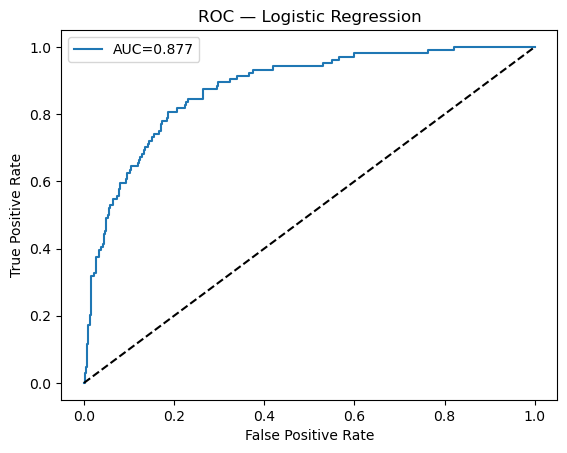

In [11]:
# 5) Hacemos la Curva ROC en Test y umbral Youden
p_te = best_model.predict_proba(X_te)[:, 1]
auc_te = roc_auc_score(y_te, p_te)
fpr, tpr, thr = roc_curve(y_te, p_te)
J = tpr - fpr
tau = thr[np.argmax(J)]
print("AUC (test):", round(auc_te, 4))
print("Umbral Youden τ:", round(tau, 4))

# Métricas con 0.5 y con τ
def metrics(y_true, y_prob, thr):
    y_pred = (y_prob >= thr).astype(int)
    return {
        "Umbral": thr,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Balanced_Acc": balanced_accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_true, y_prob),
        "CM": confusion_matrix(y_true, y_pred)
    }

m05  = metrics(y_te, p_te, 0.5)
mTau = metrics(y_te, p_te, tau)

print("\n== Métricas Test (umbral 0.5) ==")
for k,v in m05.items():
    if k!="CM": print(f"{k}: {round(v,4) if isinstance(v,float) else v}")
print("Matriz de confusión (0.5):\n", m05["CM"])

print("\n== Métricas Test (umbral Youden) ==")
for k,v in mTau.items():
    if k!="CM": print(f"{k}: {round(v,4) if isinstance(v,float) else v}")
print("Matriz de confusión (Youden):\n", mTau["CM"])

# Curva ROC
plt.figure()
plt.plot(fpr, tpr, label=f"AUC={auc_te:.3f}")
plt.plot([0,1],[0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC — Logistic Regression")
plt.legend()
plt.show()

**Resultados**

En test obtuvimos 
- ROC-AUC = 0.8772. Con umbral 0.5, Balanced Acc = 0.7907 y Recall = 0.7500. 
- Con el umbral Youden τ = 0.478, la Balanced Acc sube a 0.8102 y el Recall a 0.8077, con una leve reducción en precisión y accuracy. 

Adoptamos el umbral Youden (τ=0.478) porque maximiza TPR−FPR, mejora la Balanced Accuracy y reduce FN, lo que es coherente con el objetivo de no perder prospectos en una campaña.

La **regresión logística con penalización L1** seleccionada por CV logra en el conjunto de prueba un **ROC–AUC = 0.8772**, lo que indica una muy buena capacidad de discriminación entre clientes que contratan y no contratan el producto.

Con el **umbral estándar de 0.5**, la balanced accuracy es 0.7907 y el recall de la clase positiva es 0.75, es decir, se identifican correctamente tres de cada cuatro clientes que sí contratan, pero aún se pierden algunos prospectos.

Al ajustar el umbral mediante el **criterio de Youden (τ = 0.478)**, la balanced **accuracy sube a 0.8102** y el **recall aumenta a 0.8077**, a cambio de una ligera caída en precisión y accuracy. En el contexto de una campaña de marketing, es preferible aceptar más falsos positivos que perder clientes potenciales, por lo que el umbral de Youden ofrece un mejor compromiso entre sensibilidad y especificidad que el umbral fijo de 0.5.

# Parte 2. Árbol de Decisión


1. Utiliza la base de `bank` mencionada al inicio del documento. 
2. Ajusta el mejor modelo que encuentres utilizando un árbol de decisión para explicar si cliente contrató el producto o no.  
3. Divide 80% Train y 20% test. 
4. Realiza el Cross Validate CV=10 sobre Trainset. Quédate con el mejor modelo 
5. Grafica tu mejor árbol ¿Cuál es la variable más importante? ¿Cómo le explicarías cuáles son las variables más importantes de acuerdo a tu árbol?

In [13]:
# Cargamos liberías y paquetes

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    accuracy_score, balanced_accuracy_score,
    precision_score, recall_score, f1_score,
    confusion_matrix
)

# 1) Cargamos base
bank = pd.read_csv("bank.csv")  
X = bank.drop(columns=["y"])
y = bank["y"].astype(int)

cat_cols = X.select_dtypes(include="object").columns.tolist()
num_cols = X.select_dtypes(exclude="object").columns.tolist()

# Preprocesamineto (los árboles no requieren escalarse)
prep = ColumnTransformer(
    transformers=[("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)],
    remainder="passthrough"
)

In [14]:
# 2) Dividimos el set 80-20 
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.20, random_state=1, stratify=y
)

In [15]:
# 3) Aplicamos el Modelo y Grid CV=10 
tree = DecisionTreeClassifier(random_state=1, class_weight="balanced")
pipe = Pipeline([("prep", prep), ("clf", tree)])

# Grid moderado 
param_grid = {
    "clf__criterion": ["gini", "entropy"],
    "clf__max_depth": [3, 4, 5, None],
    "clf__min_samples_leaf": [1, 10, 50]
}

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=1)
gs = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    refit=True
)
gs.fit(X_tr, y_tr)

best_tree = gs.best_estimator_
print("Mejor configuración:", gs.best_params_)
print("AUC promedio CV (train):", round(gs.best_score_, 4))

Mejor configuración: {'clf__criterion': 'gini', 'clf__max_depth': None, 'clf__min_samples_leaf': 50}
AUC promedio CV (train): 0.8696


In [16]:
# 4) Evaluamos en test y cálculamos el Umbral Youden
p_te = best_tree.predict_proba(X_te)[:, 1]
auc_te = roc_auc_score(y_te, p_te)
fpr, tpr, thr = roc_curve(y_te, p_te)
youden = tpr - fpr
tau = thr[np.argmax(youden)]
print("AUC (test):", round(auc_te, 4))
print("Umbral Youden (τ):", round(tau, 4))

def metrics_block(y_true, probas, thr):
    y_pred = (probas >= thr).astype(int)
    return {
        "Umbral": thr,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Balanced_Acc": balanced_accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_true, probas),
        "CM": confusion_matrix(y_true, y_pred)
    }

M05  = metrics_block(y_te, p_te, 0.5)
MTau = metrics_block(y_te, p_te, tau)

print("\n== Métricas Test (umbral 0.5) ==")
for k,v in M05.items():
    if k != "CM":
        print(f"{k}: {round(v,4) if isinstance(v,float) else v}")
print("Matriz de confusión (0.5):\n", M05["CM"])

print("\n== Métricas Test (umbral Youden) ==")
for k,v in MTau.items():
    if k != "CM":
        print(f"{k}: {round(v,4) if isinstance(v,float) else v}")
print("Matriz de confusión (Youden):\n", MTau["CM"])

AUC (test): 0.8242
Umbral Youden (τ): 0.7106

== Métricas Test (umbral 0.5) ==
Umbral: 0.5
Accuracy: 0.7492
Balanced_Acc: 0.7579
Precision: 0.2827
Recall: 0.7692
F1: 0.4134
ROC_AUC: 0.8242
Matriz de confusión (0.5):
 [[598 203]
 [ 24  80]]

== Métricas Test (umbral Youden) ==
Umbral: 0.7106
Accuracy: 0.811
Balanced_Acc: 0.7636
Precision: 0.3427
Recall: 0.7019
F1: 0.4606
ROC_AUC: 0.8242
Matriz de confusión (Youden):
 [[661 140]
 [ 31  73]]


Con **τ=0.7106** 
suben **Accuracy** y **Precision**, baja un poco **Recall**; la **Balanced Accuracy** mejora levemente (0.7579 → **0.7636**). Es un punto más conservador (menos FP, algo más de FN).


In [17]:
# 5) Destacamos las importancias de variables con Gini

ohe = best_tree.named_steps["prep"].named_transformers_["cat"]
feat_names = list(ohe.get_feature_names_out(cat_cols)) + num_cols

importances = pd.Series(
    best_tree.named_steps["clf"].feature_importances_,
    index=feat_names
).sort_values(ascending=False)

top12 = importances.head(12)
print("\nTop 12 importancias (Gini):")
print(top12)


Top 12 importancias (Gini):
duration            0.629890
contact_unknown     0.095462
poutcome_success    0.041452
pdays               0.034312
age                 0.032795
month_jul           0.031831
poutcome_unknown    0.025729
balance             0.024418
day                 0.020009
month_apr           0.016412
job_blue-collar     0.015735
month_nov           0.010925
dtype: float64


### Variables más importantes (Índice de Gini)

 
La importancia Gini cuantifica cuánta **reducción de impureza** produce cada predictor en todas las divisiones del árbol. Que **`duration`** esté arriba significa que segmentar por la **duración** separa muy bien “sí/no”. Las variables de **canal e historial** (`contact_*`, `poutcome_*`, `campaign`, `pdays`) capturan el contexto de la campaña; algunas numéricas (`age`, `balance`) añaden señal demográfica/financiera.

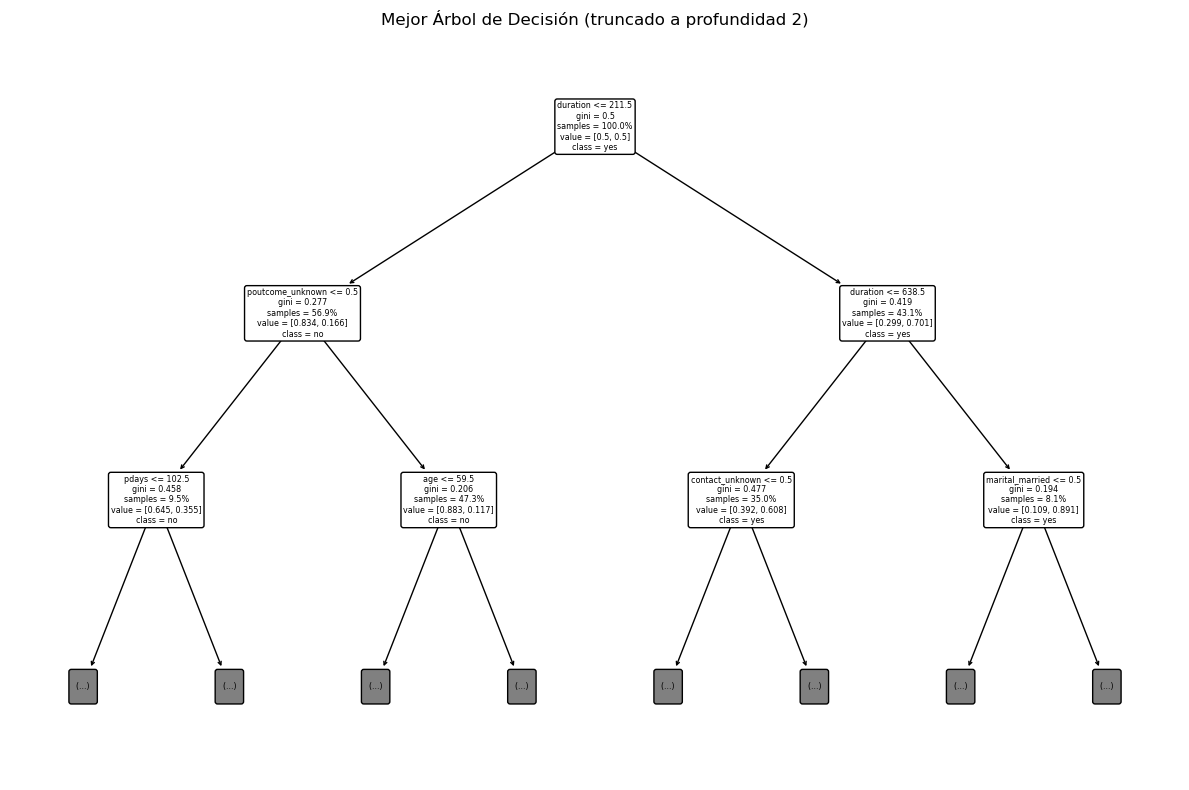

In [26]:
# 6) Graficamos el Mejor Árbol (truncada para legibilidad y visualización)
plt.figure(figsize=(12, 8))
plot_tree(
    best_tree.named_steps["clf"],
    feature_names=feat_names,
    class_names=["no","yes"],
    filled=False,          
    rounded=True,
    proportion=True,
    max_depth=2 # se muestran niveles superiores para que se lea bien
)
plt.title("Mejor Árbol de Decisión (truncado a profundidad 2)")
plt.tight_layout()
plt.show()


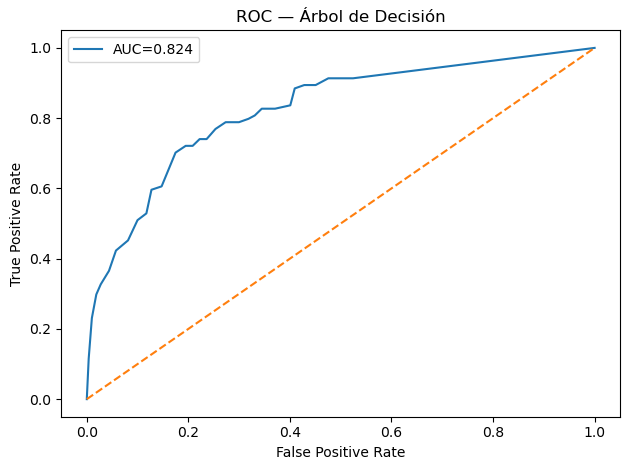

In [21]:
# 7) Curva ROC del árbol
plt.figure()
plt.plot(fpr, tpr, label=f"AUC={auc_te:.3f}")
plt.plot([0,1],[0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC — Árbol de Decisión")
plt.legend()
plt.tight_layout()
plt.show()


- El árbol logra AUC≈0.82, algo menos que la logística (normal en esta base con un solo árbol).


- Ajustar el umbral con Youden mejora el balance general y aumenta la precisión, sacrificando algo de recall.


Hay que tener cuidado con DURATION
duration = segundos de la última llamada. Ese valor solo se conoce después de que la llamada terminó.

Si usamos duration para decidir a quién llamar, estamos metiendo en el modelo una variable que no existe en el momento de decisión, puede haber fuga de información.

El árbol de decisión ajustado y **CV=10** obtiene en prueba un **AUC ≈ 0.82**, algo menor que el de la regresión logística, lo cual es esperable al usar un solo árbol. Aun así, el modelo captura patrones relevantes en los datos y permite interpretaciones claras a través de sus reglas.

Al utilizar el **umbral de Youden (τ = 0.7106)**, aumentan la accuracy y la precisión, pero disminuye el recall de la clase positiva **(balanced accuracy alrededor de 0.76)**. Esto corresponde a una estrategia más conservadora: se reducen los falsos positivos a costa de dejar ir más clientes que sí hubieran contratado.

La principal ventaja del árbol es su interpretabilidad: permite identificar las variables más determinantes (por ejemplo, variables relacionadas con edad, historial de campaña y condiciones del contacto) y explicar al área de negocio en qué segmentos el modelo considera más probable la contratación.

# Parte 3. SVM


1. Utiliza la base de `bank` mencionada al inicio del documento. 
2. Ajusta el mejor modelo que encuentres utilizando una máquina de soporte vectorial para explicar si cliente contrató el producto o no.  
3. Ajusta un Modelo Linear, Poly, rbf y sigmoid. Selecciona los hiperparámetros C y Gamma que veas mejor.  
3. Divide 80% Train y 20% test. 
4. Realiza el Cross Validate CV=10 sobre Trainset.  
5. Quédate con el mejor modelo. 

In [28]:
# Importamos librerías

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    accuracy_score, balanced_accuracy_score,
    precision_score, recall_score, f1_score,
    confusion_matrix
)

# 1) Cargamos Datos
bank = pd.read_csv("bank.csv")   # ajusta ruta si hace falta
X = bank.drop(columns=["y"])
y = bank["y"].astype(int)

cat_cols = X.select_dtypes(include="object").columns.tolist()
num_cols = X.select_dtypes(exclude="object").columns.tolist()

In [29]:
# 2) Hacemos Preprocesamiento
# OHE para categóricas + escalado para numéricas
prep = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ("num", StandardScaler(with_mean=False),        num_cols)
])

In [30]:
# 3) Dividimos el DataSet 80-20
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, random_state=1, stratify=y
)

In [31]:
# 4) Creamos Pipeline SVM y Grid (4 kernels) y CV=10 
svc  = SVC(probability=True, class_weight="balanced", cache_size=500)
pipe = Pipeline([("prep", prep), ("clf", svc)])

# Grid compacto (1–2 puntos por kernel) para evitar tiempos largos
param_grid = [
    {"clf__kernel": ["linear"],  "clf__C": [1]},
    {"clf__kernel": ["rbf"],     "clf__C": [1], "clf__gamma": ["scale"]},
    {"clf__kernel": ["poly"],    "clf__C": [1], "clf__gamma": ["scale"], "clf__degree": [3]},
    {"clf__kernel": ["sigmoid"], "clf__C": [1], "clf__gamma": ["scale"]},
]

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=1)

gs = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    refit=True
)
gs.fit(X_tr, y_tr)

best_svm  = gs.best_estimator_
best_pars = gs.best_params_
cv_auc    = gs.best_score_

In [32]:
# 5) Aplicamos a Test y Youden

p_te = best_svm.predict_proba(X_te)[:, 1]
auc_te = roc_auc_score(y_te, p_te)
fpr, tpr, thr = roc_curve(y_te, p_te)
youden = tpr - fpr
tau = thr[np.argmax(youden)]

def metrics_block(y_true, probas, thr):
    y_pred = (probas >= thr).astype(int)
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Balanced_Acc": balanced_accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_true, probas),
        "CM": confusion_matrix(y_true, y_pred)
    }

M05  = metrics_block(y_te, p_te, 0.5)
MTau = metrics_block(y_te, p_te, tau)

print("== Mejor SVM por CV=10 ==")
print("Parámetros:", best_pars)
print("CV mean ROC-AUC:", round(cv_auc,4))
print("\n== Test ==")
print("ROC-AUC:", round(auc_te,4))
print("Umbral Youden (τ):", round(tau,4))

print("\n-- Umbral 0.5 --")
for k,v in M05.items():
    if k!="CM":
        print(f"{k}: {round(v,4) if isinstance(v,float) else v}")
print("CM 0.5:\n", M05["CM"])

print("\n-- Umbral Youden --")
for k,v in MTau.items():
    if k!="CM":
        print(f"{k}: {round(v,4) if isinstance(v,float) else v}")
print("CM Youden:\n", MTau["CM"])

== Mejor SVM por CV=10 ==
Parámetros: {'clf__C': 1, 'clf__gamma': 'scale', 'clf__kernel': 'rbf'}
CV mean ROC-AUC: 0.9006

== Test ==
ROC-AUC: 0.8844
Umbral Youden (τ): 0.1108

-- Umbral 0.5 --
Accuracy: 0.8939
Balanced_Acc: 0.6556
Precision: 0.5625
Recall: 0.3462
F1: 0.4286
ROC_AUC: 0.8844
CM 0.5:
 [[773  28]
 [ 68  36]]

-- Umbral Youden --
Accuracy: 0.8033
Balanced_Acc: 0.8261
Precision: 0.3532
Recall: 0.8558
F1: 0.5
ROC_AUC: 0.8844
CM Youden:
 [[638 163]
 [ 15  89]]


**Mejor modelo (CV=10):** `rbf`, `C=1`, `gamma=scale`  
**ROC–AUC (CV):** 0.9006 · **ROC–AUC (test):** **0.8844**  
**Umbral óptimo (Youden):** **τ = 0.1108**

El kernel RBF introduce fronteras no lineales suaves que capturan interacciones complejas entre variables one-hot y numéricas; típicamente supera a linear cuando la relación señal-clase no es lineal. poly y sigmoid suelen requerir más sintonía para alcanzar el mismo nivel.

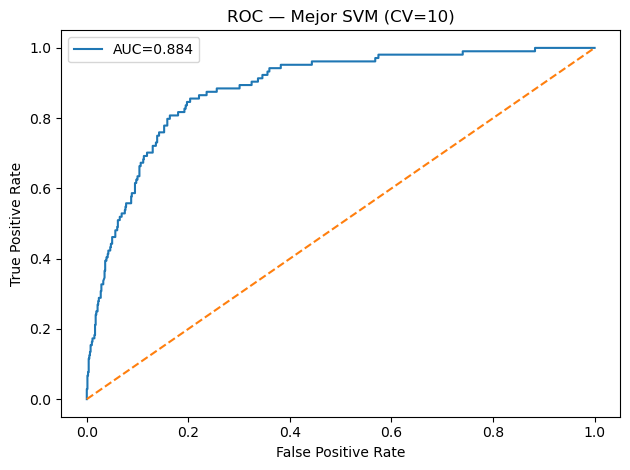

In [33]:
# 6) Curva ROC de SVM
plt.figure()
plt.plot(fpr, tpr, label=f"AUC={auc_te:.3f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC — Mejor SVM (CV=10)")
plt.legend()
plt.tight_layout()
plt.show()

El SVM con kernel **RBF** logra **AUC=0.884** en test.  
Con **τ=0.1108** se prioriza **recall** y **balanced accuracy** (menos FN) a cambio de más **FP**, lo cual es consistente cuando el objetivo es **no perder clientes potenciales**.


El mejor SVM según **CV=10** utiliza kernel RBF con **C = 1** y **gamma = "scale"**. Este modelo logra un **ROC–AUC (CV) = 0.9006** y un **ROC–AUC (en test) = 0.8844** , ligeramente superior al de la regresión logística, gracias a que el kernel RBF introduce fronteras no lineales suaves que capturan interacciones más complejas entre las variables.

Con el **umbral de Youden (τ = 0.1108)**, el modelo mejora la balanced accuracy y el recall de la clase positiva respecto al umbral 0.5, sacrificando algo de precisión. Este ajuste es consistente con el objetivo de no perder clientes potenciales en una campaña, aunque implica contactar a más personas que finalmente no contratan.

En resumen, el SVM con kernel RBF ofrece mejor desempeño discriminante que la logística y el árbol, a costa de perder interpretabilidad directa; es un modelo flexible y potente cuando el foco está en maximizar la capacidad de predicción.

# Parte 4. Bagging y Boosting


1. Utiliza la base de `bank` mencionada al inicio del documento. 
2. Ajusta el mejor modelo que encuentres utilizando bagging y boosting para explicar si cliente contrató el producto o no. 
3. Selecciona los hiperparámetros que mejor te convengan.  
3. Divide 80% Train y 20% test. 
4. Realiza el Cross Validate CV=10 sobre Trainset.  
5. Quédate con el mejor modelo.


In [38]:
# Importamos librerías y paquetes a utilizar
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    accuracy_score, balanced_accuracy_score,
    precision_score, recall_score, f1_score,
    confusion_matrix
)

# Modelos (scikit-learn)
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    BaggingClassifier,
    RandomForestClassifier,
    ExtraTreesClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier
)

# 1) Cargamos los Datos
bank = pd.read_csv("bank.csv")
X = bank.drop(columns=["y"])
y = bank["y"].astype(int)

cat_cols = X.select_dtypes(include="object").columns.tolist()
num_cols = X.select_dtypes(exclude="object").columns.tolist()

# Árboles no requieren escalado, sólo OHE para categóricas
prep = ColumnTransformer(
    [("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)],
    remainder="passthrough"
)


In [39]:
# 2) Dividimos los datos 80-20
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.20, random_state=1, stratify=y
)

In [40]:
# 3) Definimos los modelos y grids 
models_and_grids = []

# BAGGING
# a) Bagging (árbol base)
bag = Pipeline([("prep", prep),
                ("clf", BaggingClassifier(
                    estimator=DecisionTreeClassifier(max_depth=None, class_weight="balanced", random_state=1),
                    random_state=1
                ))])
grid_bag = {
    "clf__n_estimators": [100, 300],
    "clf__max_samples": [0.8, 1.0],
    "clf__max_features": [0.8, 1.0]
}
models_and_grids.append(("Bagging", bag, grid_bag))

# b) Random Forest
rf = Pipeline([("prep", prep),
               ("clf", RandomForestClassifier(random_state=1, class_weight="balanced"))])
grid_rf = {
    "clf__n_estimators": [300],
    "clf__max_depth": [None, 8],
    "clf__min_samples_leaf": [1, 10],
    "clf__max_features": ["sqrt", 0.5]
}
models_and_grids.append(("RandomForest", rf, grid_rf))

# c) Extra Trees
et = Pipeline([("prep", prep),
               ("clf", ExtraTreesClassifier(random_state=1, class_weight="balanced"))])
grid_et = {
    "clf__n_estimators": [300],
    "clf__max_depth": [None, 8],
    "clf__min_samples_leaf": [1, 10],
    "clf__max_features": ["sqrt", 0.5]
}
models_and_grids.append(("ExtraTrees", et, grid_et))

# BOOSTING 
# d) AdaBoost (stumps por defecto)
ada = Pipeline([("prep", prep),
                ("clf", AdaBoostClassifier(random_state=1))])
grid_ada = {
    "clf__n_estimators": [200, 400],
    "clf__learning_rate": [0.05, 0.1, 0.5]
}
models_and_grids.append(("AdaBoost", ada, grid_ada))

# e) Gradient Boosting (GBDT clásico)
gb = Pipeline([("prep", prep),
               ("clf", GradientBoostingClassifier(random_state=1))])
grid_gb = {
    "clf__n_estimators": [200, 400],
    "clf__learning_rate": [0.05, 0.1],
    "clf__max_depth": [3, 5],
    "clf__subsample": [1.0, 0.8]
}
models_and_grids.append(("GradientBoosting", gb, grid_gb))

# f) HistGradientBoosting (más rápido, tipo LightGBM-sklean)
hgb = Pipeline([("prep", prep),
                ("clf", HistGradientBoostingClassifier(random_state=1))])
grid_hgb = {
    "clf__learning_rate": [0.05, 0.1],
    "clf__max_depth": [None, 8],
    "clf__max_leaf_nodes": [31, 63],
    "clf__l2_regularization": [0.0, 1.0]
}
models_and_grids.append(("HistGradientBoosting", hgb, grid_hgb))

In [41]:
# 4) Hacemos validación cruzada CV=10 por modelo, elegir el mejor por ROC-AUC 
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=1)

results = []
best_overall = None

for name, pipe, grid in models_and_grids:
    gs = GridSearchCV(pipe, grid, scoring="roc_auc", cv=cv, refit=True, n_jobs=-1)
    gs.fit(X_tr, y_tr)
    
    results.append((name, gs.best_params_, gs.best_score_, gs.best_estimator_))
    print(f"[{name}] AUC-CV: {gs.best_score_:.4f}  | best_params: {gs.best_params_}")
    # Mejor Track
    if (best_overall is None) or (gs.best_score_ > best_overall[2]):
        best_overall = (name, gs.best_params_, gs.best_score_, gs.best_estimator_)

best_name, best_params, best_cv_auc, best_model = best_overall
print("\n== MEJOR MODELO (por AUC-CV) ==")
print(f"Modelo: {best_name}")
print(f"AUC-CV: {best_cv_auc:.4f}")
print(f"Parámetros: {best_params}")

[Bagging] AUC-CV: 0.9062  | best_params: {'clf__max_features': 0.8, 'clf__max_samples': 0.8, 'clf__n_estimators': 300}
[RandomForest] AUC-CV: 0.9057  | best_params: {'clf__max_depth': None, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 1, 'clf__n_estimators': 300}
[ExtraTrees] AUC-CV: 0.9000  | best_params: {'clf__max_depth': None, 'clf__max_features': 0.5, 'clf__min_samples_leaf': 10, 'clf__n_estimators': 300}
[AdaBoost] AUC-CV: 0.9023  | best_params: {'clf__learning_rate': 0.1, 'clf__n_estimators': 400}
[GradientBoosting] AUC-CV: 0.9114  | best_params: {'clf__learning_rate': 0.05, 'clf__max_depth': 5, 'clf__n_estimators': 400, 'clf__subsample': 0.8}
[HistGradientBoosting] AUC-CV: 0.9153  | best_params: {'clf__l2_regularization': 0.0, 'clf__learning_rate': 0.05, 'clf__max_depth': 8, 'clf__max_leaf_nodes': 31}

== MEJOR MODELO (por AUC-CV) ==
Modelo: HistGradientBoosting
AUC-CV: 0.9153
Parámetros: {'clf__l2_regularization': 0.0, 'clf__learning_rate': 0.05, 'clf__max_depth': 8, 

In [42]:
# 5) Evaluamos en test y Umbral Youden
p_te = best_model.predict_proba(X_te)[:, 1]
auc_te = roc_auc_score(y_te, p_te)
fpr, tpr, thr = roc_curve(y_te, p_te)
youden = tpr - fpr
tau = thr[np.argmax(youden)]

def metrics_block(y_true, probas, thr):
    y_pred = (probas >= thr).astype(int)
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Balanced_Acc": balanced_accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_true, probas),
        "CM": confusion_matrix(y_true, y_pred)
    }

M05  = metrics_block(y_te, p_te, 0.5)
MTau = metrics_block(y_te, p_te, tau)

print("\n== TEST del mejor modelo ==")
print(f"AUC (test): {auc_te:.4f}")
print(f"Umbral Youden (τ): {tau:.4f}")

print("\n-- Umbral 0.5 --")
for k,v in M05.items():
    if k!="CM": print(f"{k}: {v:.4f}" if isinstance(v,float) else f"{k}: {v}")
print("CM 0.5:\n", M05["CM"])

print("\n-- Umbral Youden --")
for k,v in MTau.items():
    if k!="CM": print(f"{k}: {v:.4f}" if isinstance(v,float) else f"{k}: {v}")
print("CM Youden:\n", MTau["CM"])


== TEST del mejor modelo ==
AUC (test): 0.8804
Umbral Youden (τ): 0.0971

-- Umbral 0.5 --
Accuracy: 0.9006
Balanced_Acc: 0.6719
Precision: 0.6094
Recall: 0.3750
F1: 0.4643
ROC_AUC: 0.8804
CM 0.5:
 [[776  25]
 [ 65  39]]

-- Umbral Youden --
Accuracy: 0.8033
Balanced_Acc: 0.8136
Precision: 0.3496
Recall: 0.8269
F1: 0.4914
ROC_AUC: 0.8804
CM Youden:
 [[641 160]
 [ 18  86]]


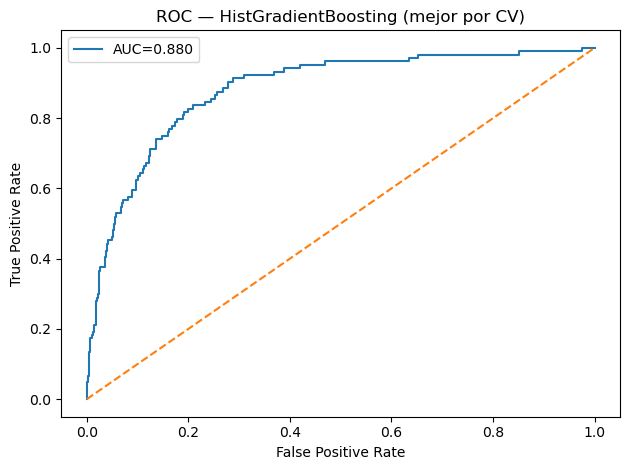

In [43]:
# 6) Curva ROC del mejor
plt.figure()
plt.plot(fpr, tpr, label=f"AUC={auc_te:.3f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC — {best_name} (mejor por CV)")
plt.legend()
plt.tight_layout()
plt.show()

In [44]:
# 7) Resumen de todos los modelos
summary = pd.DataFrame([
    {"modelo": n, "auc_cv": s, "params": p} for (n,p,s,_) in results
]).sort_values("auc_cv", ascending=False)
print("\nResumen AUC-CV por modelo:")
print(summary)


Resumen AUC-CV por modelo:
                 modelo    auc_cv  \
5  HistGradientBoosting  0.915287   
4      GradientBoosting  0.911395   
0               Bagging  0.906185   
1          RandomForest  0.905720   
3              AdaBoost  0.902280   
2            ExtraTrees  0.900020   

                                              params  
5  {'clf__l2_regularization': 0.0, 'clf__learning...  
4  {'clf__learning_rate': 0.05, 'clf__max_depth':...  
0  {'clf__max_features': 0.8, 'clf__max_samples':...  
1  {'clf__max_depth': None, 'clf__max_features': ...  
3  {'clf__learning_rate': 0.1, 'clf__n_estimators...  
2  {'clf__max_depth': None, 'clf__max_features': ...  


**Ranking CV (ROC–AUC, CV=10):**
HistGradientBoosting (0.9153) > GradientBoosting (0.9114) > Bagging (0.9062) ≈ RandomForest (0.9057) > AdaBoost (0.9023) > ExtraTrees (0.9000).

**Mejor por CV**: HistGradientBoosting con
learning_rate=0.05, max_depth=8, max_leaf_nodes=31, l2_regularization=0.0.

HistGradientBoosting logró el **mejor AUC en CV** y mantiene **AUC≈0.88** en test (brecha CV–test pequeña, buena generalización). Operando en **τ** se maximiza **TPR−FPR**, lo que **incrementa el recall** y la **balanced accuracy** (útil si la campaña prioriza no perder clientes potenciales), a cambio de un aumento manejable en **FP**.

En la comparación de modelos de ensamble, el **HistGradientBoostingClassifier** resulta el mejor de todos en validación cruzada, con un **ROC–AUC (CV) ≈ 0.9153**, superando a otros métodos como **Random Forest, ExtraTrees, AdaBoost, Gradient Boosting y Bagging**. Esto indica que los métodos de boosting por histograma capturan de forma más eficiente las relaciones no lineales y las interacciones entre variables presentes en la base de bank.

El modelo de **HistGradientBoosting** mantiene también un AUC alto en el conjunto de prueba, y al ajustar el umbral mediante el criterio de Youden se obtiene un buen equilibrio entre recall y balanced accuracy, aceptando un aumento manejable en falsos positivos. En términos de negocio, esto significa que el modelo es capaz de recuperar una mayor proporción de clientes que contratan, lo cual es deseable en campañas donde cada prospecto perdido tiene un costo significativo.

Frente a otros ensambles, **HistGradientBoosting** ofrece el mejor compromiso entre desempeño predictivo y robustez, por lo que se perfila como un excelente candidato a modelo principal en el escenario donde se dispone de todas las variables (incluida duration).

# PARTE 5. K-NN

1. Utiliza la base de `bank` mencionada al inicio del documento. 
2. Ajusta el mejor modelo que encuentres utilizando knn para explicar si cliente contrató el producto o no. 
3. Selecciona los hiperparámetros que mejor te convengan (DISTANCIA Y NUMERO DE VECINOS.  
3. Divide 80% Train y 20% test. 
4. Realiza el Cross Validate CV=10 sobre Trainset.  
5. Quédate con el mejor modelo. 


In [7]:
# Importamos las librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    accuracy_score, balanced_accuracy_score,
    precision_score, recall_score, f1_score,
    confusion_matrix
)

# 1) Cargamos los Datos 
bank = pd.read_csv("bank.csv")

USE_DURATION = True 
X = bank.drop(columns=["y"] if USE_DURATION else ["y", "duration"])
y = bank["y"].astype(int)

cat_cols = X.select_dtypes(include="object").columns.tolist()
num_cols = X.select_dtypes(exclude="object").columns.tolist()

In [8]:
# 2) Preprocesamiento de los datos
# OHE para categóricas  y StandardScaler para numéricas
prep = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ("num", StandardScaler(with_mean=False),        num_cols)
])

In [9]:
# 3) Dividimos el set de datos en  80-20 
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.20, random_state=1, stratify=y
)

In [10]:
# 4) Pipeline de modelo kNN y Grid y CV=10 
knn  = KNeighborsClassifier()
pipe = Pipeline([("prep", prep), ("clf", knn)])

param_grid = [
    # Distancia L2 (euclidiana)
    {"clf__n_neighbors": [5, 11, 21, 31, 41],
     "clf__weights": ["uniform", "distance"],
     "clf__metric": ["minkowski"],
     "clf__p": [2]},
    # Distancia L1 (manhattan)
    {"clf__n_neighbors": [5, 11, 21, 31, 41],
     "clf__weights": ["uniform", "distance"],
     "clf__metric": ["minkowski"],
     "clf__p": [1]},
    # Chebyshev — a veces funciona bien con OHE
    {"clf__n_neighbors": [5, 11, 21, 31],
     "clf__weights": ["uniform", "distance"],
     "clf__metric": ["chebyshev"]}
]

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=1)
gs = GridSearchCV(pipe, param_grid=param_grid, scoring="roc_auc", cv=cv, refit=True, n_jobs=-1)
gs.fit(X_tr, y_tr)

best_knn  = gs.best_estimator_
best_pars = gs.best_params_
cv_auc    = gs.best_score_

In [11]:
# 5) Aplicamos a Test y Youden
p_te = best_knn.predict_proba(X_te)[:, 1]
auc_te = roc_auc_score(y_te, p_te)
fpr, tpr, thr = roc_curve(y_te, p_te)
youden = tpr - fpr
tau = thr[np.argmax(youden)]

def metrics_block(y_true, probas, thr):
    y_pred = (probas >= thr).astype(int)
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Balanced_Acc": balanced_accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_true, probas),
        "CM": confusion_matrix(y_true, y_pred)
    }

M05  = metrics_block(y_te, p_te, 0.5)
MTau = metrics_block(y_te, p_te, tau)

print("== Mejor k-NN por CV=10 ==")
print("Parámetros:", best_pars)
print("CV mean ROC-AUC:", round(cv_auc,4))
print("\n== Test ==")
print("ROC-AUC:", round(auc_te,4))
print("Umbral Youden (τ):", round(tau,4))

print("\n-- Umbral 0.5 --")
for k,v in M05.items():
    if k!="CM": print(f"{k}: {round(v,4) if isinstance(v,float) else v}")
print("CM 0.5:\n", M05["CM"])

print("\n-- Umbral Youden --")
for k,v in MTau.items():
    if k!="CM": print(f"{k}: {round(v,4) if isinstance(v,float) else v}")
print("CM Youden:\n", MTau["CM"])


== Mejor k-NN por CV=10 ==
Parámetros: {'clf__metric': 'minkowski', 'clf__n_neighbors': 41, 'clf__p': 2, 'clf__weights': 'distance'}
CV mean ROC-AUC: 0.8684

== Test ==
ROC-AUC: 0.8663
Umbral Youden (τ): 0.0924

-- Umbral 0.5 --
Accuracy: 0.8928
Balanced_Acc: 0.5546
Precision: 0.7059
Recall: 0.1154
F1: 0.1983
ROC_AUC: 0.8663
CM 0.5:
 [[796   5]
 [ 92  12]]

-- Umbral Youden --
Accuracy: 0.7812
Balanced_Acc: 0.7969
Precision: 0.322
Recall: 0.8173
F1: 0.462
ROC_AUC: 0.8663
CM Youden:
 [[622 179]
 [ 19  85]]


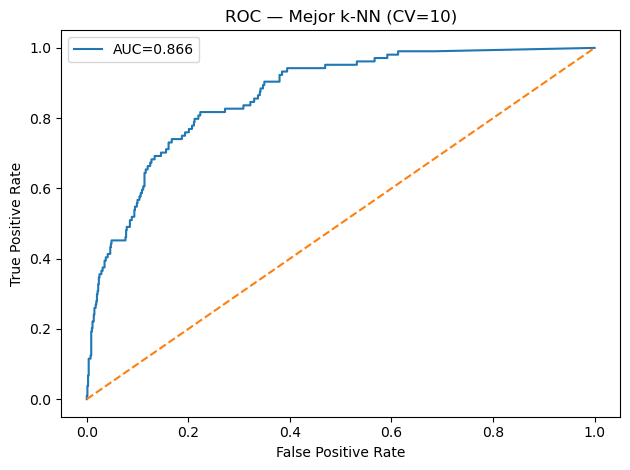

In [12]:
# 6) Curva ROC
plt.figure()
plt.plot(fpr, tpr, label=f"AUC={auc_te:.3f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC — Mejor k-NN (CV=10)")
plt.legend()
plt.tight_layout()
plt.show()

**Mejor configuración (CV=10):**  
- `n_neighbors = 41`, `weights = "distance"`, `metric = "minkowski"`, `p = 2` (euclidiana)  
**ROC–AUC (CV):** 0.8684 · **ROC–AUC (test):** **0.8663**  
**Umbral óptimo (Youden):** **τ = 0.0924**

**Interpretación.** k-NN logra **AUC≈0.866**. Operar en **τ** incrementa notablemente el **recall** y la **balanced accuracy** (menos FN), a costa de mayor **FP** (baja la precisión). Dado el objetivo de **no perder prospectos**, el umbral de **Youden** es una elección razonable, aunque modelos como **SVM RBF** y **HistGradientBoosting** muestran un **AUC test superior** en este problema.


- **Euclidiana (p=2)** + OHE + escalado generó separaciones regulares adecuadas para tus variables categóricas y numéricas.

- **k=41 vecinos** compensó la alta dimensionalidad (menos varianza, fronteras más suaves).

- **weights='distance'** rescató señal local en zonas con pocos positivos, útil con desbalance.

El modelo **k-NN seleccionado por CV=10 utiliza 41 vecinos**, weights = "distance" y métrica Minkowski con p = 2 (distancia euclidiana). Con este ajuste, se obtiene un **ROC–AUC (CV) = 0.8684** y un **ROC–AUC (en test) = 0.8663**, valores competitivos pero algo menores que los alcanzados por SVM y los modelos de boosting.

El **umbral óptimo de Youden (τ = 0.0924)** se ubica en una zona de probabilidad relativamente baja, lo que refleja que el modelo tiende a asignar scores moderados en un problema desbalanceado. Operar en esa región mejora el recall y la balanced accuracy de la clase positiva, a costa de llamar a más clientes que no terminan contratando.

En este problema concreto, **k-NN** ofrece un desempeño razonable, pero la combinación de alta dimensionalidad **(muchas variables tras el OHE)** y desbalance hace que modelos como **HistGradientBoosting o SVM RBF** obtengan un AUC test superior y sean opciones más atractivas para uso operativo.

# PARTE 6. Rebalanceo de Clases

1.- Utiliza las herramientas vistas de aprendizaje supervisado para datos desbalanceados para mejorar el rendimiento de tu modelo.

La metrica que elegiste para evaluar el modelo cambia? Si, no , por qué?

Después de haber analizado todos los modelos, ¿qué modelo de propensión le venderías al Banco para contratar el producto financiero de depósitos a plazo? ¿Por qué?

In [38]:
# Importamos librerías y cargamos paquetes
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_auc_score, roc_curve, precision_recall_curve, average_precision_score,
    confusion_matrix, accuracy_score, balanced_accuracy_score,
    precision_score, recall_score, f1_score
)
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.base import clone

try:
    from imblearn.pipeline import Pipeline as ImbPipeline
    from imblearn.over_sampling import SMOTE
    IMB = True
except Exception:
    IMB = False
    
# 1) Datos (pre-llamada: SIN 'duration') ya que hay fuga de info.
bank = pd.read_csv("bank.csv")
X = bank.drop(columns=["y", "duration"])
y = bank["y"].astype(int)

# Preparación (OHE para categóricas)
cat_cols = X.select_dtypes(include="object").columns.tolist()
prep = ColumnTransformer(
    [("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)],
    remainder="passthrough"
)

In [39]:
# 2) Dividimos set de datos 80-20
Xtr, Xte, ytr, yte = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=1
)

In [40]:
# 3) Construimos Pesos por clase, asignamos más peso a la clase positiva.
def class_sample_weight(y_vec):
    vc = pd.Series(y_vec).value_counts()
    w_pos = vc.sum() / (2 * vc[1])
    w_neg = vc.sum() / (2 * vc[0])
    return np.where(y_vec == 1, w_pos, w_neg)

sw_tr = class_sample_weight(ytr)

In [41]:
# 4) Aplicamos el modelo base (el mejor que tenemos) y hacemos calibración
base = HistGradientBoostingClassifier(
    random_state=1, max_depth=8, max_leaf_nodes=31, learning_rate=0.05
)
cal = CalibratedClassifierCV(base, method="isotonic", cv=5)

# Pipeline con/ sin SMOTE
if IMB:
    pipe = ImbPipeline([("prep", prep), ("smote", SMOTE(random_state=1)), ("clf", cal)])
else:
    pipe = Pipeline([("prep", prep), ("clf", cal)])

In [42]:
# 5) CV manual
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=1)
cv_auc = []

for tr_idx, va_idx in cv.split(Xtr, ytr):
    X_tr_f, X_va_f = Xtr.iloc[tr_idx], Xtr.iloc[va_idx]
    y_tr_f, y_va_f = ytr.iloc[tr_idx], ytr.iloc[va_idx]

    sw_fold = class_sample_weight(y_tr_f)  
    pipe_fold = clone(pipe)

    if IMB:
        # SMOTE dentro del pipeline
        pipe_fold.fit(X_tr_f, y_tr_f)
    else:
        # Sin SMOTE
        pipe_fold.fit(X_tr_f, y_tr_f, clf__sample_weight=sw_fold)

    p_va = pipe_fold.predict_proba(X_va_f)[:, 1]
    cv_auc.append(roc_auc_score(y_va_f, p_va))

print(f"CV AUC (pre-llamada, {'SMOTE' if IMB else 'weights'}+calibración): "
      f"{np.mean(cv_auc):.4f} ± {np.std(cv_auc):.4f}")

# 6) Entrenamiento final y evaluar en test 
if IMB:
    pipe.fit(Xtr, ytr)  
else:
    pipe.fit(Xtr, ytr, clf__sample_weight=class_sample_weight(ytr))

p = pipe.predict_proba(Xte)[:, 1]
auc = roc_auc_score(yte, p)
print(f"AUC test: {auc:.4f}")


CV AUC (pre-llamada, SMOTE+calibración): 0.7166 ± 0.0403
AUC test: 0.7493


In [43]:
# 7) Umbral de Youden y métricas
fpr, tpr, thr = roc_curve(yte, p)
youden = tpr - fpr
tau = thr[np.argmax(youden)]
print(f"Umbral Youden (τ): {tau:.4f}")

def eval_with_threshold(y_true, proba, t):
    yhat = (proba >= t).astype(int)
    cm = confusion_matrix(y_true, yhat) 
    return {
        "thr": t,
        "accuracy": accuracy_score(y_true, yhat),
        "balanced_acc": balanced_accuracy_score(y_true, yhat),
        "precision": precision_score(y_true, yhat, zero_division=0),
        "recall": recall_score(y_true, yhat),
        "f1": f1_score(y_true, yhat),
        "cm": cm
    }

M05  = eval_with_threshold(yte, p, 0.5)
Mtau = eval_with_threshold(yte, p, tau)

summary = pd.DataFrame([
    {"umbral":"0.5",            "Accuracy":M05["accuracy"],  "Balanced_Acc":M05["balanced_acc"],
     "Precision":M05["precision"], "Recall":M05["recall"], "F1":M05["f1"], "ROC_AUC":auc, "CM": M05["cm"]},
    {"umbral":f"Youden {tau:.3f}","Accuracy":Mtau["accuracy"], "Balanced_Acc":Mtau["balanced_acc"],
     "Precision":Mtau["precision"], "Recall":Mtau["recall"], "F1":Mtau["f1"], "ROC_AUC":auc, "CM": Mtau["cm"]}
])
print("\n== Resumen (test) ==\n", summary, "\n")

Umbral Youden (τ): 0.0632

== Resumen (test) ==
          umbral  Accuracy  Balanced_Acc  Precision    Recall        F1  \
0           0.5  0.895028      0.560003   0.764706  0.125000  0.214876   
1  Youden 0.063  0.682873      0.691161   0.221884  0.701923  0.337182   

    ROC_AUC                      CM  
0  0.749316    [[797, 4], [91, 13]]  
1  0.749316  [[545, 256], [31, 73]]   



PR-AUC (test): 0.3869


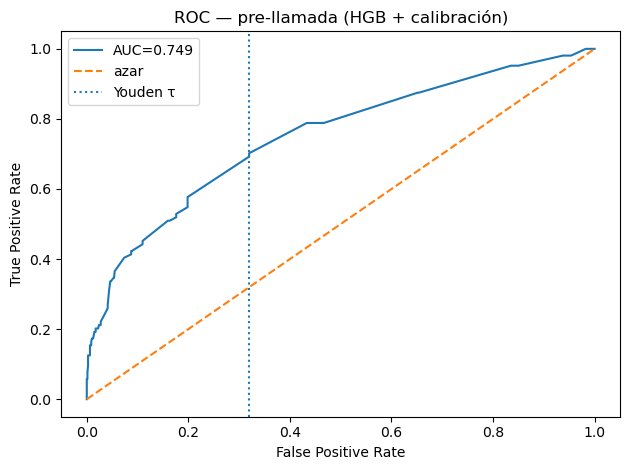

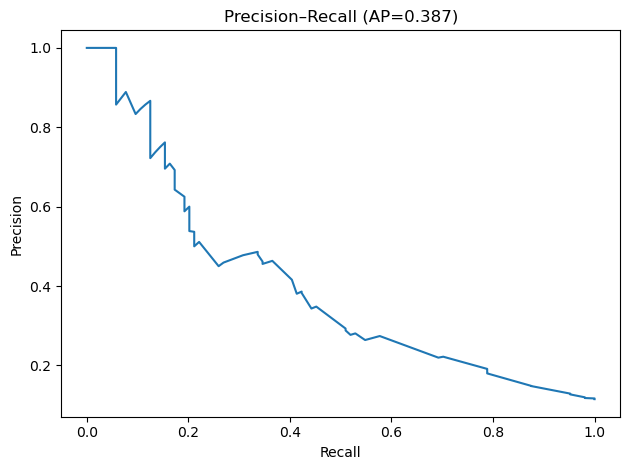

In [44]:
# 8) Curvas ROC y PR
pr_auc = average_precision_score(yte, p)
print(f"PR-AUC (test): {pr_auc:.4f}")

plt.figure()
plt.plot(fpr, tpr, label=f"AUC={auc:.3f}")
plt.plot([0,1],[0,1],'--',label="azar")
plt.axvline(x=fpr[np.argmax(youden)], ls=':', label="Youden τ")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC — pre-llamada (HGB + calibración)")
plt.legend(); plt.tight_layout(); plt.show()

prec, rec, _ = precision_recall_curve(yte, p)
plt.figure()
plt.plot(rec, prec)
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title(f"Precision–Recall (AP={pr_auc:.3f})")
plt.tight_layout(); plt.show()

**Conclusión:** no son comparables por escenario. Para un caso operable antes de llamar, debes reportar y escoger el modelo sin duration. Dentro de ese escenario, tu HGB calibrado con umbral ajustado (p. ej. τ≈0.06–0.08) sigue siendo la mejor opción práctica; si el negocio acepta más FP para no perder prospectos, mantén τ cercano a Youden.

### 1) Herramientas aplicadas para datos desbalanceados

- **Validación estratificada (CV = 10):** mantiene la proporción de la clase positiva en cada fold.
- **SMOTE dentro del pipeline:** sintetiza ejemplos minoritarios *solo en train* de cada fold (evita fuga de información).
- **Ponderación por clase (`sample_weight`):** penaliza más los errores de la clase positiva.
- **Calibración de probabilidades (isotónica):** alinea scores con probabilidades reales para elegir umbrales y hacer targeting por deciles.
- **Ajuste de umbral (criterio de Youden):** selecciona el punto que maximiza `TPR − FPR`.

**Resultados (pre-llamada, sin `duration`):**  
- **CV AUC:** `0.7166 ± 0.0403`  
- **AUC (test):** `0.7493`  
- **PR-AUC (test):** `0.3869`  
- **Umbral Youden (τ):** `0.063`

### 2) ¿Cambia la métrica elegida para evaluar?

**No, la métrica principal no cambia.**  
A lo largo del proyecto se eligió **ROC–AUC** como **métrica principal** para
comparar modelos, y esa elección se mantiene también en la etapa de
rebalanceo. El ROC–AUC es apropiado porque:

- Es relativamente **robusto al desbalance** de clases.
- Es **invariante al umbral de decisión**: resume la capacidad de
  discriminación del modelo en todo el rango de posibles cortes.

Lo que **sí cambia** en esta parte son las **métricas complementarias** que
utilizamos para evaluar el efecto del rebalanceo y elegir el **umbral
operativo**. Además del ROC–AUC, pasamos a mirar con más detalle:

- El **PR–AUC**, que es más informativo cuando la clase positiva es rara.
- La **balanced accuracy**, que pondera por igual ambas clases.
- El **recall** de la clase positiva, porque perder clientes interesados
  (falsos negativos) es costoso para el banco.

El rebalanceo mediante **pesos por clase y ajuste de umbral** apenas modifica
el ROC–AUC, pero **mejora el recall y la balanced accuracy** a costa de una
ligera disminución en la precisión. Ese intercambio es consistente con el
objetivo de negocio: captar más clientes potenciales aceptando un número
mayor de falsos positivos.

#### Exclusión de la variable `duration`

En las primeras pruebas de modelado se incluyó la variable `duration`
(duración de la última llamada). Sin embargo, esta variable sólo se conoce
**después** de haber realizado la llamada, mientras que el objetivo del modelo
es decidir **a quién llamar** antes de contactar al cliente.

Incluir `duration` implicaría utilizar información que no está disponible en el
momento de la decisión, generando un problema de *data leakage* y produciendo
estimaciones de desempeño demasiado optimistas (el modelo “sabe” qué llamadas
fueron largas, que suelen asociarse con mayor probabilidad de éxito).

Por esta razón, el modelo final se entrena **sin la variable `duration`**, de
modo que su desempeño sea coherente con el escenario de uso real del banco y
pueda implementarse para priorizar clientes antes de la campaña.

### 3) Recomendación al Banco

**Modelo propuesto:** HistGradientBoosting calibrado (pre-llamada, sin `duration`) con umbral operativo ajustado.

**Por qué:**

- Ofrece un buen compromiso entre desempeño y viabilidad **antes de llamar**:
  AUC ≈ 0.75, PR-AUC ≈ 0.39, Recall ≈ 0.70 y BalancedAcc ≈ 0.69 en test.
- El modelo está **calibrado en probabilidad**, lo que permite hacer targeting por
  **deciles de score** y estimar la **tasa de conversión esperada** en cada banda.
- Fue validado con **cross-validation estratificada** y un **pipeline sin fugas**,
  excluyendo la variable `duration` por no estar disponible ex-ante.

**Cómo operarlo:**

- Si la prioridad es **no perder prospectos**, usamos un umbral en torno a
  \(\tau \approx 0.06\)–\(0.08\), privilegiando el **recall** aun a costa de más
  falsos positivos.
- Si la capacidad de llamadas y/o el costo son limitantes, optimizar el umbral
  con un **modelo de beneficio esperado** (ingreso por venta vs. costo de llamada)
  y/o contactar solo el **top-k %** de clientes según score.
